# Earth Observation - satellite images classification
### Built a simple model using SaANN CNN class for EO satellite images classification between 'cloudy', 'desert', 'green_area', 'water'.

Dataset courtesy: mahmoudreda55 ([kagglehub](https://www.kaggle.com/mahmoudreda55)) - Satellite Remote Sensing Image -RSI-CB256 - All Data files © Original Authors

code for dataset:

    >>> import kagglehub

    >>> path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")

Please note that some data engineering was applied in order to get a dataset ready for SaANN's CNN model:

1. The *path* is a string that leads to a directory containing all images 
2. The images are separated within directory which names reflect the classes that the model is training on
3. The images are then passed to SaNNN's image processor for resizing and upload

## Part 1 - Set up your model

The following is an example on how to set-up you model 

In [ ]:
# Satellite images
path_EO = r"...\.cache\kagglehub\datasets\mahmoudreda55\satellite-image-classification\versions\1\data" #for Windows

In [ ]:
# Automatic 
from saann.processing import ImageProcessing

IP = ImageProcessing(images_path=path_EO)
X_train, X_test, y_train, y_test, list_classes = IP.ready_dataset(size=98, amount=150, shuffle = True, remove_resized=True, split_test_percentage=0.3)

GPU failed: DLL load failed while importing cublas: The specified module could not be found.
List of directories:  ['cloudy', 'desert', 'green_area', 'water']
Resizing images to (98 x 98)
Processing image # 100
Processing image # 200
Processing image # 300
Processing image # 400
Processing image # 500
Processing image # 600
Dataset has been cleaned.
Dataset has been shuffled.
Dataset is ready and has been split into Train (length = 420) and Test (length = 180) sets.


### Parameters

*amount* : limits the amount of images per class | Default is None (no limits)
    
*size* : resized the images to a square with resolution size x size

*shuffle* : Randomly shuffles your dataset

*remove_resized*: SaANN creates a directory within the parent direcotory names "resized". If True, it will remove this directory after upload

*split_test_percentage*: Splits dataset into a Train (1-percentage) and Test (percentage)

GPU not available. Computing on CPU
Estimated time: 22 minutes.

Training for 20 Epochs with learning rate: 0.0001
Epoch    1/20, Loss: 1.45285
Epoch    2/20, Loss: 1.05456
Epoch    4/20, Loss: 1.05348
Epoch    6/20, Loss: 0.84265
Epoch    8/20, Loss: 0.80946
Epoch   10/20, Loss: 0.81383
Epoch   12/20, Loss: 0.71171
Epoch   14/20, Loss: 0.72749
Epoch   16/20, Loss: 0.75697
Epoch   18/20, Loss: 0.68453
Epoch   20/20, Loss: 0.68732

Final 'cross-entropy' loss on training data: 0.71360


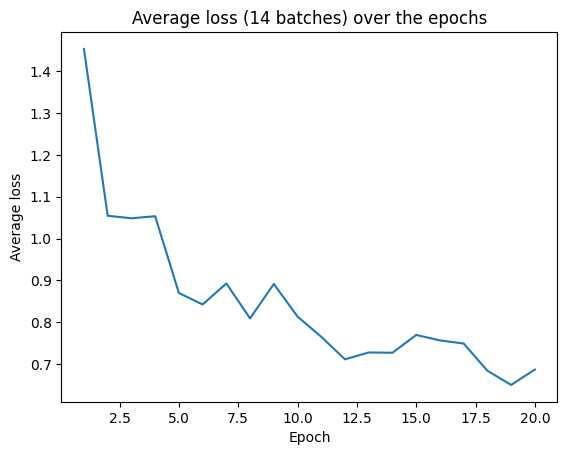

In [ ]:
from saann.models import CNN

# Initialize the model
model_cnn = CNN(filter_size = 3, num_filters = 32, padding = 1, stride = 1, activation_function = "relu", init_function = "he")
# Get the size of the input after passing through the convolution array
input_size = model_cnn.get_input_size(X_train=X_train)
# Define the layers
layer_info = [
    (input_size, 256, 'relu', 'he'),
    (256, 128, 'relu', 'he'),
    (128, y_train.shape[1], 'softmax', 'he')
]
# Construct the layers
model_cnn.construct(layers_info=layer_info, learning_rate=1e-4)
# Perform training
final_pred = model_cnn.fit(X_train = X_train, y_train=y_train, epochs = 20, batch_size = 32, wd = 0.00001, graphical = True, real_time = False, log_plot = False)


In [4]:
# Make predictions
y_pred = model_cnn.predict(X_test=X_test)

print(y_pred)

[[0.05712578 0.01720352 0.90378593 0.02188477]
 [0.89105339 0.02289887 0.02974306 0.05630469]
 [0.06700252 0.05964296 0.02183453 0.85151998]
 [0.21854326 0.16113716 0.40969666 0.21062292]
 [0.20797143 0.22088811 0.40787795 0.16326251]
 [0.15960058 0.10131842 0.19418789 0.5448931 ]
 [0.04299254 0.04021056 0.85955769 0.05723921]
 [0.63711895 0.17730087 0.11624763 0.06933254]
 [0.14947207 0.10047541 0.62654064 0.12351188]
 [0.25583764 0.33409941 0.08459601 0.32546694]
 [0.21722237 0.10651862 0.05574149 0.62051753]
 [0.26673773 0.21094445 0.41400849 0.10830934]
 [0.12021571 0.23570673 0.29095814 0.35311942]
 [0.08188454 0.05854389 0.32828976 0.5312818 ]
 [0.22028343 0.35667797 0.21108382 0.21195478]
 [0.16123962 0.29014816 0.50636441 0.0422478 ]
 [0.09424062 0.66983437 0.07328    0.16264501]
 [0.05092709 0.82399764 0.02684541 0.09822986]
 [0.26670829 0.25534549 0.16747606 0.31047015]
 [0.25311914 0.16126668 0.15034707 0.43526711]
 [0.03671546 0.86454042 0.04310632 0.0556378 ]
 [0.34946842 

In [ ]:
from saann.metrics import Metrics
# Initialize the Metrics class
metrics = Metrics(y_pred=y_pred, y_test=y_test)

Confusion matrix:
 [[36 12  2  2]
 [ 2 30  1  0]
 [ 0  0 35  5]
 [ 3  3 17 32]]

Class                 1      2      3      4 
------------------
Balanced accuracy | 0.827, 0.904, 0.866, 0.763
Precision         | 0.878, 0.667, 0.636, 0.821
Recall            | 0.692, 0.909, 0.875, 0.582
Specificity       | 0.961, 0.898, 0.857, 0.944
F1-score          | 0.774, 0.769, 0.737, 0.681
------------------
Macro F1: 0.740
Weighted F1: 0.736
MCC: 0.164

AUC: 0.944


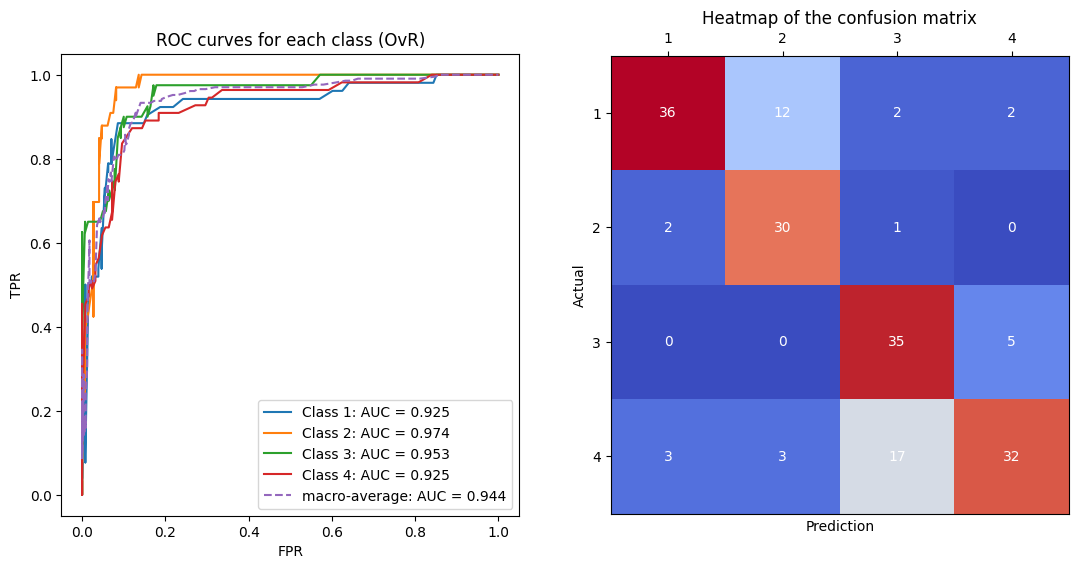

In [6]:
# Get a fast report of the model's metrics
metrics.report()

## Part 2: Save and Load model

If you trained a model that you think is worth saving, you can save it as a pickle file by using:

In [7]:
# save model as a pickle file
model_cnn.save_model("model_EO.pickle")

Model saved: model_EO.pickle


And it can be loaded easily by using the *load_model* function inside **models**

In [ ]:
from saann.models import load_model

model = load_model("model_EO.pickle")

In [ ]:
# For testing, we get the whole dataset
IP = ImageProcessing(images_path=path_EO)
X_train, X_test, y_train, y_test, list_classes = IP.ready_dataset(size=98, amount=None, shuffle = True, remove_resized=True, split_test_percentage=0.3)

List of directories:  ['cloudy', 'desert', 'green_area', 'water']
Resizing images to (98 x 98)
Processing image # 100
Processing image # 200
Processing image # 300
Processing image # 400
Processing image # 500
Processing image # 600
Processing image # 700
Processing image # 800
Processing image # 900
Processing image # 1000
Processing image # 1100
Processing image # 1200
Processing image # 1300
Processing image # 1400
Processing image # 1500
Processing image # 1600
Processing image # 1700
Processing image # 1800
Processing image # 1900
Processing image # 2000
Processing image # 2100
Processing image # 2200
Processing image # 2300
Processing image # 2400
Processing image # 2500
Processing image # 2600
Processing image # 2700
Processing image # 2800
Processing image # 2900
Processing image # 3000
Processing image # 3100
Processing image # 3200
Processing image # 3300
Processing image # 3400
Processing image # 3500
Processing image # 3600
Processing image # 3700
Processing image # 3800
Pr

In [9]:
# Make predictions
y_pred = model_cnn.predict(X_test=X_test)

print(y_pred)

[[0.11070467 0.19955108 0.31095515 0.3787891 ]
 [0.82749116 0.02610819 0.13559381 0.01080684]
 [0.24208594 0.40778881 0.09906622 0.25105903]
 ...
 [0.10856202 0.177906   0.50827822 0.20525376]
 [0.08771958 0.01809431 0.65834096 0.23584516]
 [0.07508752 0.05662444 0.6112053  0.25708274]]


Confusion matrix:
 [[331  68  10  31]
 [ 34 322   4   6]
 [ 12   6 385  65]
 [ 29  10  77 300]]

Class                 1      2      3      4 
------------------
Balanced accuracy | 0.846, 0.908, 0.874, 0.821
Precision         | 0.815, 0.793, 0.809, 0.746
Recall            | 0.752, 0.880, 0.823, 0.721
Specificity       | 0.940, 0.937, 0.926, 0.920
F1-score          | 0.783, 0.834, 0.816, 0.733
------------------
Macro F1: 0.791
Weighted F1: 0.791
MCC: 0.180

AUC: 0.936


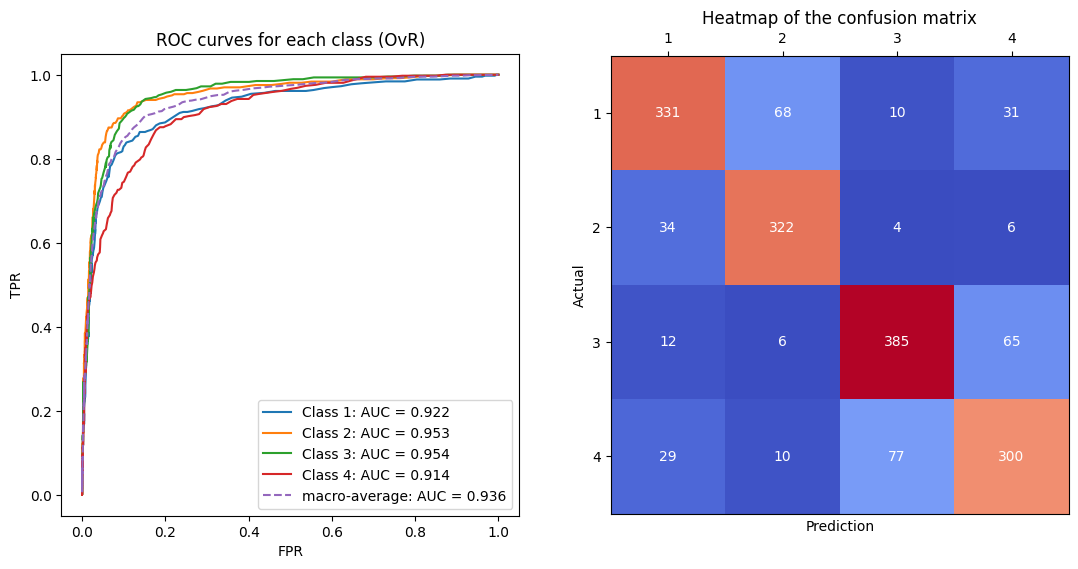

In [10]:
# check the results
metrics = Metrics(y_pred=y_pred, y_test=y_test)
metrics.report()